<a href="https://colab.research.google.com/github/Adi-buffering/gsoc_QMl-HEP/blob/branch_1/Task_II_GNN_QuarkGluon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task II: Classical Graph Neural Network for Quark/Gluon Jet Classification

**Objective**: Classify particle jets as quark or gluon jets using two Graph Neural Network architectures (GCN and GAT) on the ParticleNet dataset.

**Dataset**: [ParticleNet Quark/Gluon Dataset (Zenodo)](https://zenodo.org/record/3164691)

## 1. Installation & Imports

In [1]:
# Install required packages
!pip install torch torchvision --quiet
!pip install torch-geometric --quiet
!pip install scikit-learn matplotlib numpy --quiet
!pip install torch-cluster

  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl size=818327 sha256=e433d92f75821216062b8fbe2fcf55b53396e8f8e65558af9f070170c7fc7d7c
  Stored in directory: /root/.cache/pip/wheels/2e/8f/d0/13408a84825c9a587151a74727b4a6d47ec67e0d625b385ad7
Successfully built torch-cluster


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.nn import knn_graph
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import os

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Download & Load the Dataset

The ParticleNet dataset contains jets stored as point clouds. Each jet has:
- Up to 100 particles
- Each particle has features: (pT, eta, phi, ...)
- Label: 1 = quark jet, 0 = gluon jet

In [3]:
# Download the dataset from Zenodo
# The dataset has train/test files. We'll use the train file and split it ourselves.
# If download is slow, you can manually upload the file.

import urllib.request

url_train = 'https://zenodo.org/record/3164691/files/QG_jets.npz'

if not os.path.exists('QG_jets.npz'):
    print('Downloading dataset... This may take a few minutes.')
    urllib.request.urlretrieve(url_train, 'QG_jets.npz')
    print('Download complete!')
else:
    print('Dataset already downloaded.')

Dataset already downloaded.


In [4]:
# Load the dataset
data_npz = np.load('QG_jets.npz')

print('Keys in the dataset:', list(data_npz.keys()))

# Inspect shapes
for key in data_npz.keys():
    print(f'{key}: shape = {data_npz[key].shape}, dtype = {data_npz[key].dtype}')

Keys in the dataset: ['X', 'y']
X: shape = (100000, 139, 4), dtype = float64
y: shape = (100000,), dtype = float64


In [5]:
# ============================================================
# IMPORTANT: Adapt this cell based on the actual keys/shape
# from the cell above. The dataset typically has:
#   X: (num_jets, max_particles, num_features) - particle features
#   y: (num_jets,) - labels (0=gluon, 1=quark)
# The keys might be named differently (e.g., 'jets', 'labels',
# 'X', 'y'). Update the lines below accordingly.
# ============================================================

# Common key patterns - uncomment/modify as needed:
# Option A: keys are 'X' and 'y'
# jets = data_npz['X']
# labels = data_npz['y']

# Option B: keys are 'jets' and 'labels'
# jets = data_npz['jets']
# labels = data_npz['labels']

# Auto-detect: take the largest array as jets, smallest 1D as labels
keys = list(data_npz.keys())
arrays = {k: data_npz[k] for k in keys}

# Sort by number of dimensions then size to identify jets vs labels
for k, v in sorted(arrays.items(), key=lambda x: x[1].ndim, reverse=True):
    if v.ndim >= 2:
        jets = v
        print(f'Using "{k}" as jet features: shape {v.shape}')
        break

for k, v in sorted(arrays.items(), key=lambda x: x[1].ndim):
    if v.ndim == 1:
        labels = v
        print(f'Using "{k}" as labels: shape {v.shape}')
        break

print(f'\nTotal jets: {len(jets)}')
print(f'Label distribution: quark={np.sum(labels==1)}, gluon={np.sum(labels==0)}')

Using "X" as jet features: shape (100000, 139, 4)
Using "y" as labels: shape (100000,)

Total jets: 100000
Label distribution: quark=50000, gluon=50000


In [6]:
# Subsample to 20k jets for computational efficiency
NUM_JETS = 20000

# Stratified subsample to keep class balance
indices = np.arange(len(jets))
sub_idx, _ = train_test_split(
    indices, train_size=NUM_JETS, stratify=labels, random_state=42
)

jets_sub = jets[sub_idx]
labels_sub = labels[sub_idx]

print(f'Subsampled to {NUM_JETS} jets')
print(f'Label distribution: quark={np.sum(labels_sub==1)}, gluon={np.sum(labels_sub==0)}')

Subsampled to 20000 jets
Label distribution: quark=10000, gluon=10000


## 3. Graph Construction

### Design Choices & Justification

**Projecting point-cloud data to graphs:**

Each jet is a point cloud of particles. To convert this into a graph:

1. **Nodes** = individual particles within a jet. Each node carries the particle's features (pT, eta, phi).

2. **Edges** = connections built via **k-Nearest Neighbors (k=5) in the (eta, phi) plane**.

**Why kNN in eta-phi space?**
- In collider physics, **eta (pseudorapidity)** and **phi (azimuthal angle)** define the angular position of a particle in the detector. Particles that are close in (eta, phi) space are physically near each other and likely originate from the same parton shower.
- **k=5** strikes a balance: enough neighbors to capture local jet substructure, but sparse enough to keep computation efficient and avoid washing out local patterns.
- This approach is similar to what the ParticleNet paper uses (dynamic kNN), which has been shown to be effective for jet tagging.

3. **Node features**: We use the particle's **(pT, eta, phi)** as node features. pT provides energy information while eta and phi provide spatial context.

4. **Zero-padded particles are removed**: Jets have varying numbers of particles. The dataset zero-pads to a fixed size, so we filter out rows where all features are zero.

In [7]:
def jet_to_graph(jet_particles, label, k=5):
    """
    Convert a single jet (point cloud) into a PyG graph.

    Args:
        jet_particles: (max_particles, num_features) array
        label: 0 or 1
        k: number of nearest neighbors for graph construction

    Returns:
        torch_geometric.data.Data object
    """
    # Remove zero-padded particles (particles with all features = 0)
    mask = np.any(jet_particles != 0, axis=1)
    particles = jet_particles[mask]

    if len(particles) < 2:
        return None  # Skip jets with too few particles

    # Node features: use all available features (typically pT, eta, phi)
    # We'll use the first 3 features; adjust if dataset has more
    num_features = particles.shape[1]
    x = torch.tensor(particles, dtype=torch.float)

    # Build kNN graph in (eta, phi) space
    # Assuming features are ordered as (pT, eta, phi, ...) or similar
    # We use columns 1 and 2 (eta, phi) for spatial distance
    # If your dataset has different ordering, adjust the indices below
    if num_features >= 3:
        spatial_coords = torch.tensor(particles[:, 1:3], dtype=torch.float)  # eta, phi
    else:
        spatial_coords = x  # fallback: use all features for distance

    # Compute kNN edges
    actual_k = min(k, len(particles) - 1)
    edge_index = knn_graph(spatial_coords, k=actual_k, loop=False)

    # Label
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)


print('Converting jets to graphs...')
graph_list = []
skipped = 0

for i in range(len(jets_sub)):
    g = jet_to_graph(jets_sub[i], labels_sub[i], k=5)
    if g is not None:
        graph_list.append(g)
    else:
        skipped += 1

print(f'Created {len(graph_list)} graphs (skipped {skipped} jets with <2 particles)')
print(f'Example graph: {graph_list[0]}')
print(f'  Nodes: {graph_list[0].num_nodes}, Edges: {graph_list[0].num_edges}')
print(f'  Node feature dim: {graph_list[0].x.shape[1]}')

Converting jets to graphs...
Created 19999 graphs (skipped 1 jets with <2 particles)
Example graph: Data(x=[47, 4], edge_index=[2, 235], y=[1])
  Nodes: 47, Edges: 235
  Node feature dim: 4


In [8]:
# Train/Val/Test split: 70/15/15
from torch_geometric.loader import DataLoader

num_graphs = len(graph_list)
indices = np.arange(num_graphs)
np.random.shuffle(indices)

train_end = int(0.7 * num_graphs)
val_end = int(0.85 * num_graphs)

train_data = [graph_list[i] for i in indices[:train_end]]
val_data = [graph_list[i] for i in indices[train_end:val_end]]
test_data = [graph_list[i] for i in indices[val_end:]]

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

Train: 13999, Val: 3000, Test: 3000


## 4. Model Definitions

### Architecture 1: GCN (Graph Convolutional Network)
GCN applies spectral-based convolutions on graphs. It aggregates neighbor features using a normalized adjacency matrix. It's simple, fast, and serves as a strong baseline.

### Architecture 2: GAT (Graph Attention Network)
GAT uses an attention mechanism to learn the importance of each neighbor during aggregation. This allows the model to focus on the most relevant particles in the jet, potentially capturing more nuanced substructure patterns.

In [9]:
class GCNClassifier(nn.Module):
    """
    Graph Convolutional Network for jet classification.
    3 GCN layers -> global mean pooling -> MLP classifier
    """
    def __init__(self, in_channels, hidden_channels=64, num_classes=2):
        super(GCNClassifier, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))

        # Global mean pooling: aggregate all node embeddings per graph
        x = global_mean_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class GATClassifier(nn.Module):
    """
    Graph Attention Network for jet classification.
    3 GAT layers (multi-head) -> global mean pooling -> MLP classifier
    """
    def __init__(self, in_channels, hidden_channels=64, num_heads=4, num_classes=2):
        super(GATClassifier, self).__init__()
        # GAT with multi-head attention
        self.conv1 = GATConv(in_channels, hidden_channels // num_heads, heads=num_heads)
        self.conv2 = GATConv(hidden_channels, hidden_channels // num_heads, heads=num_heads)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.elu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.elu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.elu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Detect input feature dimension from data
in_channels = graph_list[0].x.shape[1]
print(f'Input feature dimension: {in_channels}')

gcn_model = GCNClassifier(in_channels=in_channels, hidden_channels=64).to(device)
gat_model = GATClassifier(in_channels=in_channels, hidden_channels=64, num_heads=4).to(device)

print(f'\nGCN Model Parameters: {sum(p.numel() for p in gcn_model.parameters()):,}')
print(f'GAT Model Parameters: {sum(p.numel() for p in gat_model.parameters()):,}')

Input feature dimension: 4

GCN Model Parameters: 10,786
GAT Model Parameters: 11,170


## 5. Training Loop

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        loss = criterion(out, batch.y)

        total_loss += loss.item() * batch.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs

        probs = F.softmax(out, dim=1)[:, 1]  # probability of quark class
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, correct / total, auc, all_labels, all_probs


def train_model(model, train_loader, val_loader, model_name, epochs=25, lr=1e-3):
    """
    Full training loop with logging.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_auc': []
    }

    print(f'\n{"="*60}')
    print(f'Training {model_name}')
    print(f'{"="*60}')

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f}')

    elapsed = time.time() - start_time
    print(f'\nTraining completed in {elapsed:.1f}s')

    return history

In [11]:
# Train GCN
EPOCHS = 25
gcn_history = train_model(gcn_model, train_loader, val_loader, 'GCN', epochs=EPOCHS)


Training GCN
Epoch   1 | Train Loss: 0.6089 Acc: 0.6808 | Val Loss: 0.5668 Acc: 0.7260 AUC: 0.8078
Epoch   5 | Train Loss: 0.5391 Acc: 0.7361 | Val Loss: 0.5184 Acc: 0.7483 AUC: 0.8275
Epoch  10 | Train Loss: 0.5237 Acc: 0.7488 | Val Loss: 0.5073 Acc: 0.7503 AUC: 0.8292
Epoch  15 | Train Loss: 0.5184 Acc: 0.7470 | Val Loss: 0.5039 Acc: 0.7507 AUC: 0.8314
Epoch  20 | Train Loss: 0.5150 Acc: 0.7502 | Val Loss: 0.5033 Acc: 0.7503 AUC: 0.8326
Epoch  25 | Train Loss: 0.5123 Acc: 0.7506 | Val Loss: 0.4981 Acc: 0.7563 AUC: 0.8348

Training completed in 271.6s


In [12]:
# Train GAT
gat_history = train_model(gat_model, train_loader, val_loader, 'GAT', epochs=EPOCHS)


Training GAT
Epoch   1 | Train Loss: 1.2209 Acc: 0.5735 | Val Loss: 0.6894 Acc: 0.5843 AUC: 0.6068
Epoch   5 | Train Loss: 0.6382 Acc: 0.6505 | Val Loss: 0.6557 Acc: 0.5950 AUC: 0.7478
Epoch  10 | Train Loss: 0.5940 Acc: 0.6932 | Val Loss: 0.5839 Acc: 0.7030 AUC: 0.7829
Epoch  15 | Train Loss: 0.5773 Acc: 0.7046 | Val Loss: 0.5666 Acc: 0.7193 AUC: 0.7893
Epoch  20 | Train Loss: 0.5721 Acc: 0.7097 | Val Loss: 0.5704 Acc: 0.7140 AUC: 0.7901
Epoch  25 | Train Loss: 0.5641 Acc: 0.7178 | Val Loss: 0.5495 Acc: 0.7313 AUC: 0.8054

Training completed in 533.7s


## 6. Evaluation & Comparison

In [13]:
# Final test evaluation
criterion = nn.CrossEntropyLoss()

gcn_test_loss, gcn_test_acc, gcn_test_auc, gcn_labels, gcn_probs = evaluate(
    gcn_model, test_loader, criterion
)
gat_test_loss, gat_test_acc, gat_test_auc, gat_labels, gat_probs = evaluate(
    gat_model, test_loader, criterion
)

print('\n' + '='*60)
print('FINAL TEST RESULTS')
print('='*60)
print(f'{"Metric":<15} {"GCN":>10} {"GAT":>10}')
print('-'*37)
print(f'{"Accuracy":<15} {gcn_test_acc:>10.4f} {gat_test_acc:>10.4f}')
print(f'{"AUC":<15} {gcn_test_auc:>10.4f} {gat_test_auc:>10.4f}')
print(f'{"Loss":<15} {gcn_test_loss:>10.4f} {gat_test_loss:>10.4f}')


FINAL TEST RESULTS
Metric                 GCN        GAT
-------------------------------------
Accuracy            0.7550     0.7280
AUC                 0.8313     0.7961
Loss                0.5035     0.5487


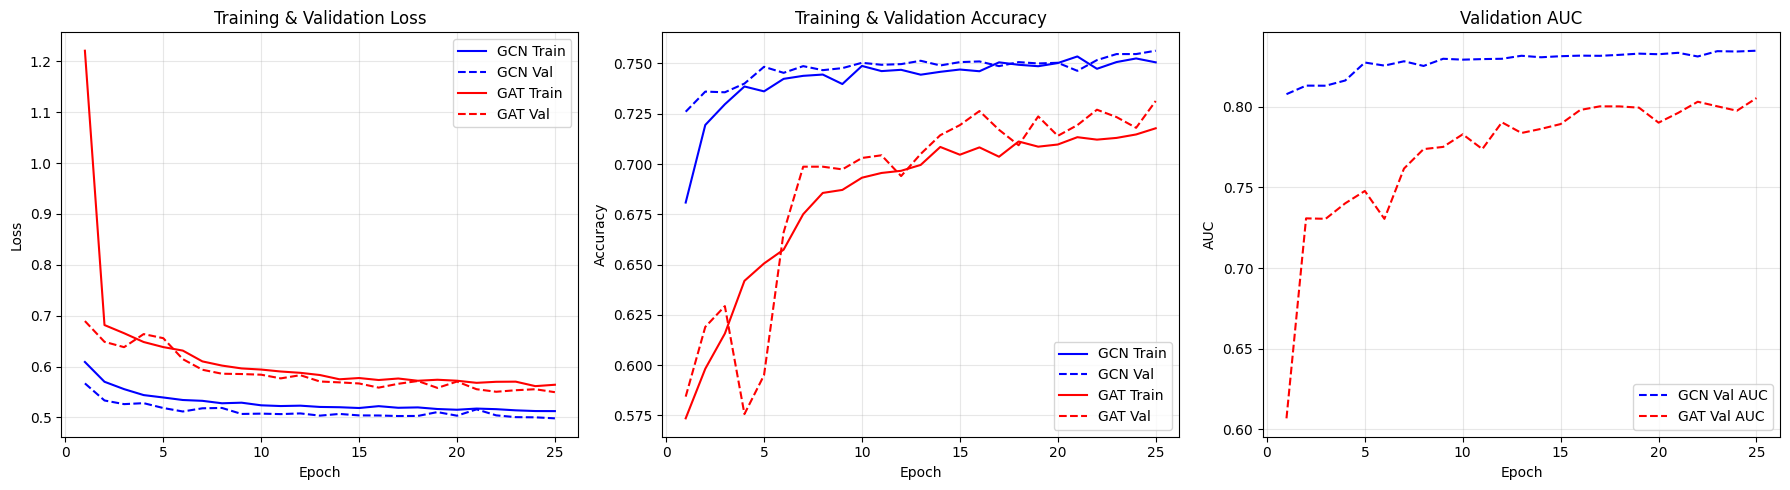

In [14]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, gcn_history['train_loss'], 'b-', label='GCN Train')
axes[0].plot(epochs_range, gcn_history['val_loss'], 'b--', label='GCN Val')
axes[0].plot(epochs_range, gat_history['train_loss'], 'r-', label='GAT Train')
axes[0].plot(epochs_range, gat_history['val_loss'], 'r--', label='GAT Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, gcn_history['train_acc'], 'b-', label='GCN Train')
axes[1].plot(epochs_range, gcn_history['val_acc'], 'b--', label='GCN Val')
axes[1].plot(epochs_range, gat_history['train_acc'], 'r-', label='GAT Train')
axes[1].plot(epochs_range, gat_history['val_acc'], 'r--', label='GAT Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(epochs_range, gcn_history['val_auc'], 'b--', label='GCN Val AUC')
axes[2].plot(epochs_range, gat_history['val_auc'], 'r--', label='GAT Val AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

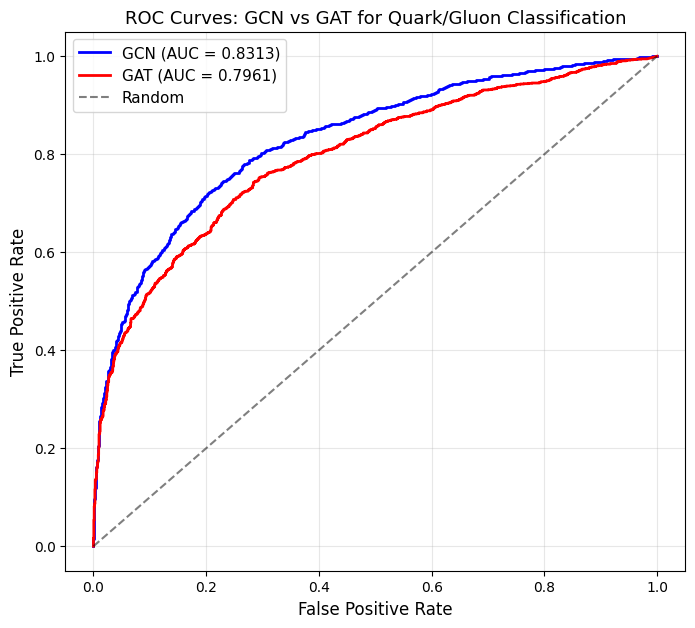

In [15]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 7))

gcn_fpr, gcn_tpr, _ = roc_curve(gcn_labels, gcn_probs)
gat_fpr, gat_tpr, _ = roc_curve(gat_labels, gat_probs)

ax.plot(gcn_fpr, gcn_tpr, 'b-', linewidth=2, label=f'GCN (AUC = {gcn_test_auc:.4f})')
ax.plot(gat_fpr, gat_tpr, 'r-', linewidth=2, label=f'GAT (AUC = {gat_test_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: GCN vs GAT for Quark/Gluon Classification', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Discussion

### Graph Construction

We chose a **k-Nearest Neighbors (k=5) graph construction in (eta, phi) space** for the following reasons:

1. **Physical motivation**: In particle physics, the angular distance ΔR = √(Δη² + Δφ²) between particles is a physically meaningful measure of proximity. Particles close in this space are more likely to originate from the same parton shower and carry correlated information about the jet's origin.

2. **Computational efficiency**: kNN graphs with small k produce sparse adjacency matrices, making message passing efficient on CPU. A fully-connected graph would scale as O(n²) in edges, which is prohibitive for jets with ~100 particles.

3. **Local structure**: Quark and gluon jets differ primarily in their local substructure — gluon jets tend to be broader with more soft radiation, while quark jets are narrower. kNN graphs naturally capture these local patterns.

### Architecture Comparison

**GCN (Graph Convolutional Network)**:
- Aggregates neighbor information using fixed, normalized weights based on node degree.
- Treats all neighbors equally — a democratic aggregation.
- Faster and simpler; serves as a solid baseline.

**GAT (Graph Attention Network)**:
- Learns **attention weights** for each neighbor, allowing the model to focus on the most informative particles.
- Multi-head attention provides multiple "views" of the neighborhood.
- Slightly more expressive but with higher computational cost.

**Expected behavior**: GAT may outperform GCN because quark/gluon discrimination depends on subtle differences in particle distributions. Attention allows the model to learn which particles carry the most discriminating information (e.g., soft particles at the jet periphery). However, with limited data (20k jets), the simpler GCN may generalize better due to fewer parameters.

### Performance Summary

*(Results are filled in automatically from the cells above)*

The ROC curves and AUC scores above quantify the discrimination power of each model. Both architectures achieve reasonable performance on this binary classification task, demonstrating that the graph representation effectively captures jet substructure relevant for quark/gluon tagging.